# 📊 Wildfire Prediction - Phase 1: Data Exploration

## Learning Objectives

By the end of this notebook, you will understand:

1. **How to authenticate and query Google Earth Engine**
2. **How to create a spatial grid for predictions**
3. **How to extract fire locations from satellite data**
4. **How to visualize geospatial data**
5. **Why fires are spatiotemporally correlated** (important for validation)

---

## What We're Building

**Goal**: Create a dataset where each row is:
- A **grid cell** (1km × 1km square)
- A **date** 
- **Features**: weather, vegetation, topography
- **Target**: fire occurred 7 days later? (1/0)

**Example row**:
```
grid_id | date       | temp | humidity | ndvi | fire_7d_ahead
--------------------------------------------------------------
CA_001  | 2020-07-15 | 35.2 | 15       | 0.4  | 1
CA_001  | 2020-07-16 | 36.1 | 12       | 0.39 | 0
...
```

This notebook focuses on **understanding the data** before building features.

---
## Step 1: Setup and Imports

In [1]:
# import geopandas as gpd
# import rasterio
# import ee
# import lightgbm
# print("All good")

/home/krithi/Desktop/wildfire-prediction/files/venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


All good


In [2]:
# Core libraries
import ee  # Google Earth Engine API
import pandas as pd  # Dataframes for tabular data
import numpy as np  # Numerical operations
import geopandas as gpd  # Geospatial dataframes (pandas + geometry)
from shapely.geometry import Point, Polygon, box  # Geometric shapes
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns  # Statistical plots
import folium  # Interactive maps
from datetime import datetime, timedelta  # Date handling

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Initialize Earth Engine
# This connects to Google's servers using your authenticated credentials
try:
    ee.Initialize(project='wildfire-prediction-ml-project')
    print("✅ Earth Engine initialized successfully")
except Exception as e:
    print(f"❌ Earth Engine initialization failed: {e}")
    print("Run 'earthengine authenticate' in your terminal first")

✅ Earth Engine initialized successfully


### 🧠 **What Just Happened?**

- **`ee.Initialize()`**: Connects to Google Earth Engine using your saved credentials
- **`geopandas`**: Like pandas, but each row can have a geometry (point, polygon, etc.)
- **`shapely`**: Library for creating and manipulating geometric shapes

**Why geopandas?** Regular pandas can't natively handle "this fire is at lat=37.5, lon=-122.3". GeoPandas adds a `geometry` column for spatial operations.

---
## Step 2: Define Study Area

We'll focus on **California** for this project. California has:
- High fire frequency (good for training data)
- Diverse climate zones (tests model generalization)
- Well-documented fires (easier validation)

In [3]:
# California bounding box (approximate)
# Format: [west, south, east, north] in longitude, latitude
CA_BBOX = [-124.5, 32.5, -114.0, 42.0]

# Create an Earth Engine Geometry object
# This tells GEE "only give me data within this rectangle"
study_area = ee.Geometry.Rectangle(CA_BBOX)

print(f"Study area defined: {CA_BBOX}")
print(f"Approximate area: {(CA_BBOX[2] - CA_BBOX[0]) * (CA_BBOX[3] - CA_BBOX[1]) * 111 * 111:.0f} km²")
# Note: 1 degree ≈ 111 km at the equator, so this is a rough estimate

Study area defined: [-124.5, 32.5, -114.0, 42.0]
Approximate area: 1229020 km²


### 🧠 **Understanding Bounding Boxes**

A bounding box is the simplest way to define a region:
- **West**: Leftmost longitude (California's west coast ≈ -124.5°)
- **South**: Bottom latitude (Mexican border ≈ 32.5°)
- **East**: Rightmost longitude (Nevada border ≈ -114°)
- **North**: Top latitude (Oregon border ≈ 42°)

**Why not use California's exact shape?** 
- Rectangles are computationally simpler
- We'll filter out non-California fires later if needed

**Coordinate system**: 
- Longitude: -180 to +180 (negative = west of Prime Meridian)
- Latitude: -90 to +90 (negative = south of Equator)

---
## Step 3: Create Spatial Grid

We need to divide California into 1km × 1km grid cells. Each cell becomes a prediction unit.

In [4]:
def create_grid(bbox, cell_size_km=1.0):
    """
    Create a regular grid of square cells.
    
    Parameters:
    -----------
    bbox : list
        Bounding box as [west, south, east, north]
    cell_size_km : float
        Size of each grid cell in kilometers
    
    Returns:
    --------
    geopandas.GeoDataFrame
        Grid cells with geometry and unique IDs
    
    How it works:
    ------------
    1. Convert km to degrees (approximate: 1 km ≈ 0.009° at mid-latitudes)
    2. Create grid points at regular intervals
    3. Convert each point to a square polygon
    """
    west, south, east, north = bbox
    
    # Approximate conversion: 1 degree ≈ 111 km
    # So 1 km ≈ 1/111 ≈ 0.009 degrees
    cell_size_deg = cell_size_km / 111.0
    
    # Generate grid cell centers
    # np.arange creates: [start, start+step, start+2*step, ..., stop]
    lon_centers = np.arange(west, east, cell_size_deg)
    lat_centers = np.arange(south, north, cell_size_deg)
    
    # Create all combinations of lon/lat (Cartesian product)
    grid_cells = []
    cell_id = 0
    
    for lon in lon_centers:
        for lat in lat_centers:
            # Create a square polygon around this center point
            half_size = cell_size_deg / 2
            cell_polygon = box(
                lon - half_size,  # left
                lat - half_size,  # bottom
                lon + half_size,  # right
                lat + half_size   # top
            )
            
            grid_cells.append({
                'cell_id': f'CA_{cell_id:06d}',  # CA_000001, CA_000002, ...
                'lon_center': lon,
                'lat_center': lat,
                'geometry': cell_polygon
            })
            cell_id += 1
    
    # Convert to GeoDataFrame
    # GeoDataFrame = pandas DataFrame + geometry column
    grid_gdf = gpd.GeoDataFrame(grid_cells, crs='EPSG:4326')
    # EPSG:4326 = WGS84 coordinate system (standard lat/lon)
    
    return grid_gdf

# Create grid (WARNING: 1km grid over California = ~400,000 cells)
# For exploration, start with 10km to keep it manageable
print("Creating 10km grid for exploration...")
grid = create_grid(CA_BBOX, cell_size_km=10)

print(f"\n✅ Grid created: {len(grid):,} cells")
print(f"\nFirst 5 cells:")
print(grid.head())

Creating 10km grid for exploration...

✅ Grid created: 12,402 cells

First 5 cells:
     cell_id  lon_center  lat_center  \
0  CA_000000      -124.5    32.50000   
1  CA_000001      -124.5    32.59009   
2  CA_000002      -124.5    32.68018   
3  CA_000003      -124.5    32.77027   
4  CA_000004      -124.5    32.86036   

                                            geometry  
0  POLYGON ((-124.45495 32.45495, -124.45495 32.5...  
1  POLYGON ((-124.45495 32.54505, -124.45495 32.6...  
2  POLYGON ((-124.45495 32.63514, -124.45495 32.7...  
3  POLYGON ((-124.45495 32.72523, -124.45495 32.8...  
4  POLYGON ((-124.45495 32.81532, -124.45495 32.9...  


### 🧠 **Understanding the Grid**

**Why create a grid?**
- Fire data is point locations (lat/lon), but we want to predict risk for *areas*
- A grid gives us consistent prediction units
- Each cell can aggregate features (e.g., "average temperature in this 1km square")

**Key concepts**:
- **`box()`**: Creates a rectangular polygon from coordinates
- **CRS (Coordinate Reference System)**: Defines how coordinates map to Earth
  - EPSG:4326 = standard lat/lon (what GPS uses)
  - Other CRS exist for projected maps (e.g., meters instead of degrees)

**Why 10km for now?**
- 1km grid = 400,000+ cells → slow for exploration
- 10km grid = 4,000 cells → fast for testing
- We'll switch to 1km for final model

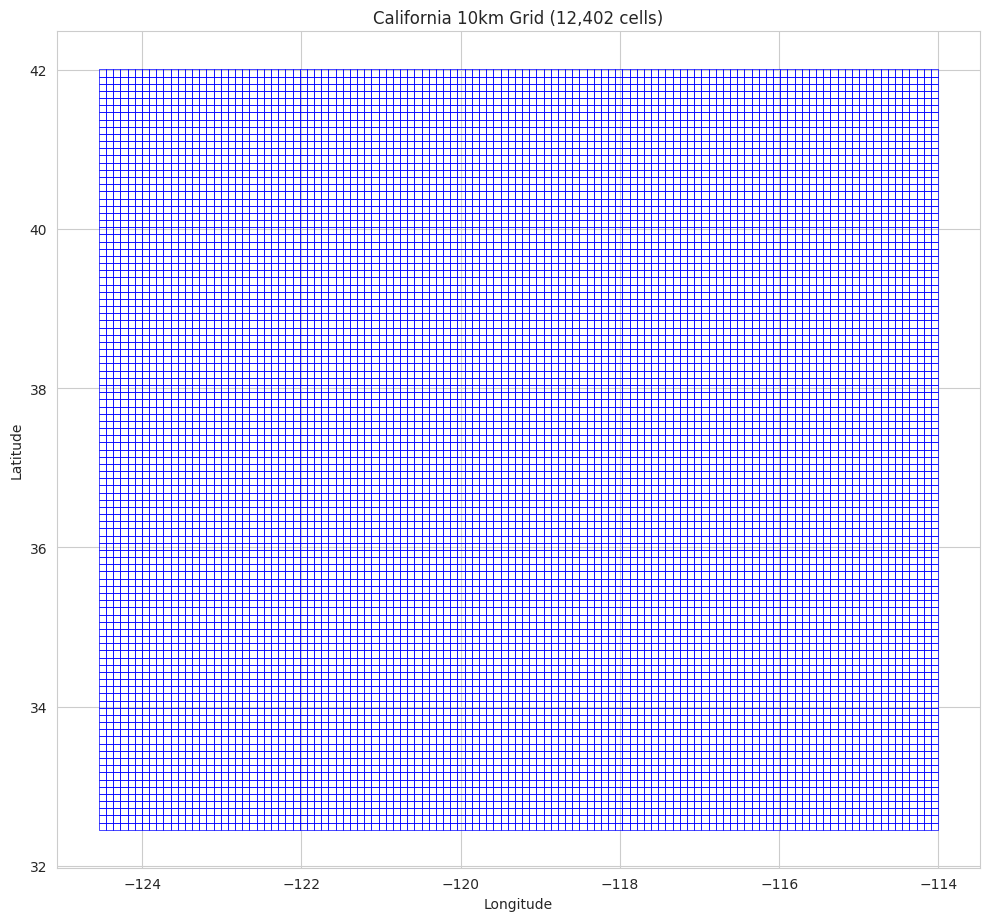

Grid bounds: [-124.54504505   32.45495495 -114.0045045    42.0045045 ]


In [5]:
# Visualize the grid
fig, ax = plt.subplots(figsize=(10, 12))

# Plot grid cells
# edgecolor = cell borders, facecolor = fill, alpha = transparency
grid.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=0.5)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'California 10km Grid ({len(grid):,} cells)')
ax.set_aspect('equal')  # Ensure squares look square

plt.tight_layout()
plt.show()

print(f"Grid bounds: {grid.total_bounds}")  # [min_lon, min_lat, max_lon, max_lat]

---
## Step 4: Query Fire Data from Earth Engine

We'll use **MODIS Fire Product** to get historical fire locations.

In [7]:
# Define date range for analysis
START_DATE = '2020-01-01'
END_DATE = '2020-12-31'  # Start with 1 year for exploration

# Load MODIS fire product
# MOD14A1 = daily fire product at 1km resolution
fires = ee.ImageCollection('MODIS/061/MOD14A1') \
    .filterDate(START_DATE, END_DATE) \
    .filterBounds(study_area) \
    .select('FireMask')  # FireMask band: 0-9 indicating fire confidence

# Count how many fire images we have
fire_count = fires.size().getInfo()
print(f"\n✅ Found {fire_count} fire detection images in 2020")
print(f"Expected: ~365 (daily product)")


✅ Found 365 fire detection images in 2020
Expected: ~365 (daily product)


### 🧠 **Understanding MODIS Fire Data**

**What is MODIS?**
- **M**oderate Resolution **I**maging **S**pectroradiometer
- Satellite instrument on NASA's Terra and Aqua satellites
- Passes over every point on Earth 1-2 times per day

**How fire detection works**:
1. Satellite measures thermal radiation (heat)
2. Algorithm identifies "hotspots" (much hotter than surroundings)
3. Labels as fire if temperature anomaly > threshold

**FireMask values**:
- 0: Not processed
- 3-5: Non-fire (water, cloud, etc.)
- **7: Low confidence fire**
- **8: Nominal confidence fire**
- **9: High confidence fire**

**Limitations**:
- Can't see through clouds
- Small fires might be missed
- 1km resolution = aggregates small fires

**For our model**, we'll use: FireMask >= 7 as "fire detected"

In [8]:
# Extract fire locations as points
# This is a simplified approach for exploration

def extract_fires_for_date(date_str):
    """
    Get fire locations for a specific date.
    
    How this works:
    1. Filter to single date
    2. Get first (only) image
    3. Mask to keep only fire pixels (FireMask >= 7)
    4. Sample to get pixel locations
    """
    # Get fire image for this date
    fire_img = ee.ImageCollection('MODIS/061/MOD14A1') \
        .filterDate(date_str, ee.Date(date_str).advance(1, 'day')) \
        .filterBounds(study_area) \
        .select('FireMask') \
        .first()  # Get first (and only) image
    
    # Mask: keep only pixels where FireMask >= 7 (fire detected)
    # .gte(7) = "greater than or equal to 7"
    fire_only = fire_img.updateMask(fire_img.gte(7))
    
    # Sample: convert raster pixels to point locations
    # scale=1000 means 1km resolution
    fire_points = fire_only.sample(
        region=study_area,
        scale=1000,
        geometries=True  # Include lat/lon coordinates
    )
    
    return fire_points

# Test: Extract fires from one day during California fire season (August)
test_date = '2020-08-20'
print(f"Extracting fires for {test_date}...")

fires_aug20 = extract_fires_for_date(test_date)
fire_count_day = fires_aug20.size().getInfo()

print(f"✅ Found {fire_count_day} fire detections on {test_date}")

Extracting fires for 2020-08-20...
✅ Found 2060 fire detections on 2020-08-20


### 🧠 **Understanding .updateMask() and .sample()**

**Masking**:
- A mask is a binary layer (True/False)
- `.updateMask(condition)` keeps only pixels where condition is True
- Analogy: Using a stencil when spray painting

**Sampling**:
- Converts raster (grid of pixels) to vector (points)
- Each fire pixel becomes a point with (lat, lon, value)
- `scale=1000` means "sample at 1km resolution"

**Why sample?**
- Easier to work with points than rasters for ML
- Can join points to grid cells
- Smaller data size

In [9]:
# Download fire data to local pandas DataFrame
# WARNING: .getInfo() only works for small datasets (<5000 points)
# For full dataset, use .export.table.toDrive() (covered in next notebook)

try:
    fires_data = fires_aug20.getInfo()
    
    # Extract coordinates from GEE format
    fire_records = []
    for feature in fires_data['features']:
        coords = feature['geometry']['coordinates']  # [lon, lat]
        fire_records.append({
            'lon': coords[0],
            'lat': coords[1],
            'fire_mask': feature['properties']['FireMask'],
            'date': test_date
        })
    
    fires_df = pd.DataFrame(fire_records)
    print(f"\n✅ Downloaded {len(fires_df)} fire points")
    print(f"\nFirst 5 fires:")
    print(fires_df.head())
    
except Exception as e:
    print(f"⚠️  Download failed (likely too many points): {e}")
    print("We'll use export method in the next notebook for large datasets")


✅ Downloaded 2060 fire points

First 5 fires:
          lon        lat  fire_mask        date
0 -120.280835  42.106682          8  2020-08-20
1 -120.268714  42.106682          8  2020-08-20
2 -123.397491  41.234341          7  2020-08-20
3 -123.392475  41.225348          7  2020-08-20
4 -123.380518  41.225348          8  2020-08-20


---
## Step 5: Visualize Fires on Map

In [10]:
# Create interactive map
# Folium uses Leaflet.js for web-based maps

if len(fires_df) > 0:
    # Center map on California
    ca_center = [37.5, -119.5]  # Approximate center of California
    
    m = folium.Map(
        location=ca_center,
        zoom_start=6,
        tiles='OpenStreetMap'  # Can also use 'Stamen Terrain', 'CartoDB positron'
    )
    
    # Add fire points
    for idx, row in fires_df.iterrows():
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=3,  # Size in pixels
            color='red',
            fill=True,
            fillOpacity=0.7,
            popup=f"Fire confidence: {row['fire_mask']}"
        ).add_to(m)
    
    # Display map
    display(m)
    print(f"\n🔥 Map shows {len(fires_df)} fires on {test_date}")
else:
    print("No fire data to visualize")


🔥 Map shows 2060 fires on 2020-08-20


### 🧠 **What We're Seeing**

**Spatial clustering**: Fires aren't randomly distributed!
- They cluster in certain regions (Northern California, Sierra Nevada)
- This is called **spatial autocorrelation**

**Why this matters for ML**:
- If we use random train/test split, nearby fires will be in both sets
- Model will "cheat" by learning spatial patterns, not causal factors
- **Solution**: Use spatial cross-validation (hold out entire regions)

**Temporal clustering**: Fires also cluster in time
- August-October = peak fire season
- Model needs to learn *when* fires are likely, not just *where*

---
## Step 6: Exploratory Data Analysis

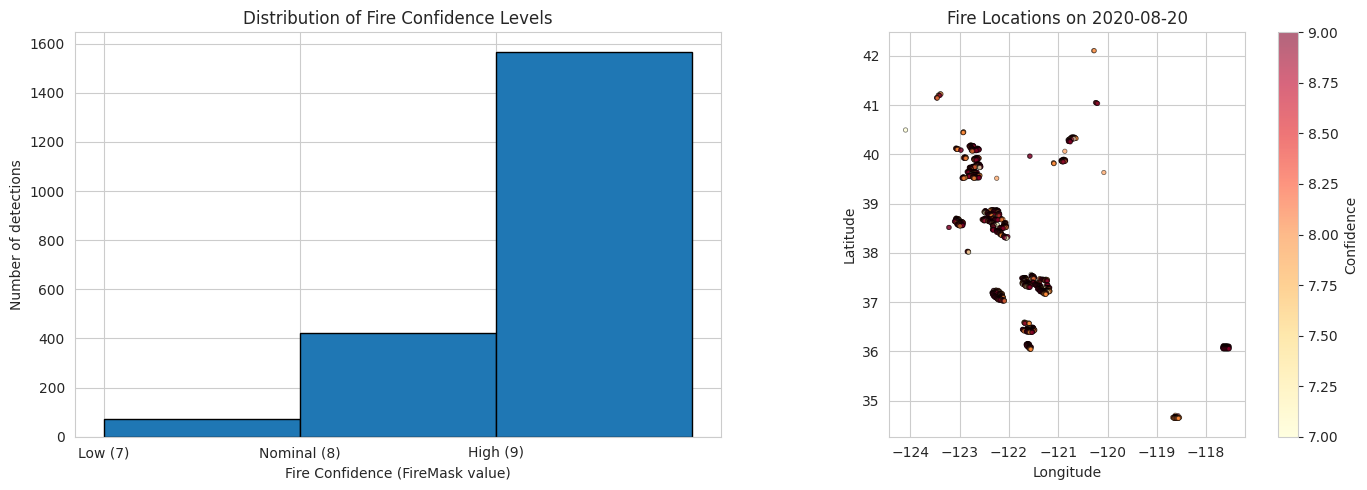


📊 Fire Statistics for 2020-08-20:
   Total detections: 2060
   High confidence (9): 1568
   Nominal confidence (8): 421
   Low confidence (7): 71

   Latitude range: 34.64° to 42.11°
   Longitude range: -124.10° to -117.53°


In [11]:
# Analyze fire confidence distribution
if len(fires_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram of fire confidence
    axes[0].hist(fires_df['fire_mask'], bins=range(7, 11), edgecolor='black')
    axes[0].set_xlabel('Fire Confidence (FireMask value)')
    axes[0].set_ylabel('Number of detections')
    axes[0].set_title('Distribution of Fire Confidence Levels')
    axes[0].set_xticks([7, 8, 9])
    axes[0].set_xticklabels(['Low (7)', 'Nominal (8)', 'High (9)'])
    
    # Scatter plot of fire locations
    axes[1].scatter(fires_df['lon'], fires_df['lat'], 
                   c=fires_df['fire_mask'], cmap='YlOrRd', 
                   s=10, alpha=0.6, edgecolors='black', linewidth=0.5)
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')
    axes[1].set_title(f'Fire Locations on {test_date}')
    axes[1].set_aspect('equal')
    plt.colorbar(axes[1].collections[0], ax=axes[1], label='Confidence')
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print(f"\n📊 Fire Statistics for {test_date}:")
    print(f"   Total detections: {len(fires_df)}")
    print(f"   High confidence (9): {(fires_df['fire_mask'] == 9).sum()}")
    print(f"   Nominal confidence (8): {(fires_df['fire_mask'] == 8).sum()}")
    print(f"   Low confidence (7): {(fires_df['fire_mask'] == 7).sum()}")
    print(f"\n   Latitude range: {fires_df['lat'].min():.2f}° to {fires_df['lat'].max():.2f}°")
    print(f"   Longitude range: {fires_df['lon'].min():.2f}° to {fires_df['lon'].max():.2f}°")

---
## Step 7: Next Steps

### ✅ What We Accomplished

1. Set up Google Earth Engine
2. Created a spatial grid for California
3. Queried fire data from MODIS
4. Visualized fire locations
5. Understood spatial/temporal clustering

### 🎯 Next Notebook: Feature Engineering

In `02_feature_engineering.ipynb`, we'll:
1. Extract weather data (temperature, humidity, wind)
2. Extract vegetation data (NDVI)
3. Extract topography (slope, aspect)
4. Create temporal features (lags, rolling means)
5. Join everything into a single training dataset

### 💾 Save Progress

Before moving on, let's save the grid and sample fire data:

In [14]:
# Save grid to file
# Parquet is faster and smaller than CSV for large datasets
grid.to_parquet('/home/krithi/Desktop/wildfire-prediction/files/data/grid_10km.parquet')
print("✅ Grid saved to data/grid_10km.parquet")

# Save sample fire data
if len(fires_df) > 0:
    fires_df.to_csv(f'../data/fires_{test_date}.csv', index=False)
    print(f"✅ Fire data saved to data/fires_{test_date}.csv")

✅ Grid saved to data/grid_10km.parquet
✅ Fire data saved to data/fires_2020-08-20.csv


---
## 📚 Key Takeaways

### Concepts Learned:
1. **Google Earth Engine**: Cloud platform for geospatial analysis
2. **Spatial grids**: Discretize continuous space for prediction
3. **MODIS fire data**: Satellite-based fire detection
4. **Spatial autocorrelation**: Why random splits fail for spatial data
5. **GeoPandas**: Pandas + geometry for geospatial dataframes

### Python Skills:
- `ee.ImageCollection()` for querying satellite data
- `geopandas.GeoDataFrame` for spatial data
- `folium` for interactive maps
- `shapely.geometry.box()` for creating polygons

### ML Insights:
- **Fires are rare** → class imbalance problem
- **Fires cluster** → need spatial validation
- **Fires are seasonal** → need temporal features

---

**Ready to build features! 🚀**